# FB15k-237 — full pipeline: TransE/RotatE baselines + custom negative sampling

Self-contained Colab notebook that reproduces every result in our D3 / DL-final
submissions:
* Section D — **Baselines**: TransE and RotatE trained with PyKEEN's pipeline under the
  unified configuration (NSSALoss, Bernoulli filtered sampler, 8 negatives per positive).
* Section E — **Custom RotatE**: two-stage negative sampling (`random`, `hard`, `mixed`)
  drawn from a scored candidate pool, same loss / sampler / hyperparameters as the baselines.
* Section F — **Sliced evaluation** on every checkpoint (per relation frequency, head /
  tail entity degree, head vs tail prediction).
* Section G — **Qualitative examples**: top-K predictions on 5 sampled test triples.
* Section H — **Headline figures** for the report.

## Unified configuration (matches M1 feedback on matched hyperparameters)
All 7 runs share:
* Loss: `NSSALoss(margin=9.0, adversarial_temperature=1.0)` — RotatE paper default.
* Sampler: Bernoulli with `filtered=True`, `num_negs_per_pos=8`.
* Model: `embedding_dim=128`, Adam `lr=1e-3`, `batch_size=1024`.
* Training: 50 epochs max, early stopping on filtered val MRR, `patience=10`.
* Seed: 42.

Only the **negative-selection strategy** changes between runs.

## How to use
1. Set Colab runtime to **GPU (T4)** (Runtime ▸ Change runtime type).
2. Run all cells in order. Section A is a one-time install.
3. Section C runs a **2-minute smoke** of the custom pipeline.
4. Sections D and E hold the **full 50-epoch commands**, commented out by default
   (uncomment what you want to re-train; total ≈ 6 h on T4).
5. Sections F–H produce the post-hoc analyses on any available checkpoint.


## A. Setup (clone repo + install dependencies)

If the repo is private and the clone fails, the cell falls back to manual upload:
create `/content/dl_kg_project/code/` in the Colab Files panel and drop the contents of
`code/` plus `requirements.txt` there.

In [1]:
import os, subprocess

REPO_URL  = "https://github.com/thaalia/dl_kg_project.git"  # adapt if the path is different
REPO_PATH = "/content/dl_kg_project"
CODE_DIR  = os.path.join(REPO_PATH, "code")

if not os.path.isdir(CODE_DIR):
    if not os.path.isdir(REPO_PATH):
        result = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_PATH],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            os.makedirs(CODE_DIR, exist_ok=True)
            print("git clone failed (private repo or no network access).")
            print("Manual upload required:")
            print(f"  1. In the Colab Files panel, navigate to {REPO_PATH}/code/")
            print("  2. Upload every .py file from the local code/ folder.")
            print("  3. Also upload requirements.txt at the repo root.")
            print("\nClone stderr:\n", result.stderr.strip())

os.chdir(REPO_PATH)
print("\nWorking directory:", os.getcwd())
if os.path.isdir("code"):
    print("Code files:", sorted(os.listdir("code")))
else:
    print("code/ still missing — please upload the Python files before continuing.")


Working directory: /content/dl_kg_project
Code files: ['__pycache__', 'evaluate_slices.py', 'negative_sampling.py', 'qualitative_examples.py', 'score_candidates.py', 'select_candidates.py', 'test_candidates.py', 'test_score_candidates.py', 'test_select_candidates.py', 'train_baseline_kge.py', 'train_pipeline_colab.ipynb', 'train_rotate_custom.py']


In [2]:
%pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.5 MB/s eta 0:00:00


In [3]:
import torch
print("PyTorch        :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU. Full training will be impractically slow on CPU.")

PyTorch        : 2.11.0+cu128
CUDA available : True
GPU            : Tesla T4


## B. Configuration

These constants mirror the CLI flags of `train_baseline_kge.py` and
`train_rotate_custom.py`. They are interpolated into the `!python …` calls below.

In [4]:
# Shared training hyperparameters
DIM                     = 128
BATCH_SIZE              = 1024
LR                      = 1e-3
EPOCHS                  = 50
PATIENCE                = 10
SEED                    = 42
MARGIN                  = 9.0
ADVERSARIAL_TEMPERATURE = 1.0
NUM_NEGS                = 8

# Custom-pipeline-only parameters
POOL_SIZE               = 64
SMOKE_STRATEGY          = "mixed"
SMOKE_HARD_FRACTION     = 0.5

print(
    f"loss=NSSALoss(margin={MARGIN}, adv_temp={ADVERSARIAL_TEMPERATURE}) | "
    f"sampler=bernoulli(filtered=True, num_negs={NUM_NEGS}) | "
    f"d={DIM} bs={BATCH_SIZE} lr={LR} epochs={EPOCHS} patience={PATIENCE} seed={SEED}"
)

loss=NSSALoss(margin=9.0, adv_temp=1.0) | sampler=bernoulli(filtered=True, num_negs=8) | d=128 bs=1024 lr=0.001 epochs=50 patience=10 seed=42


## C. Smoke test on the custom pipeline (~2 min)

Validates that the full pipeline (candidate generation → scoring → selection → loss
back-prop → save) runs end-to-end without errors. Uses a dedicated output folder
`artifacts/custom/RotatE_smoke/` so it can never overwrite a reported run.

In [5]:
!python code/train_rotate_custom.py \
    --strategy {SMOKE_STRATEGY} \
    --hard-fraction {SMOKE_HARD_FRACTION} \
    --num-negs {NUM_NEGS} \
    --pool-size {POOL_SIZE} \
    --epochs 1 \
    --batch-size 256 \
    --margin {MARGIN} \
    --adversarial-temperature {ADVERSARIAL_TEMPERATURE} \
    --seed {SEED} \
    --limit-batches 10 \
    --limit-val-eval 200 \
    --run-label RotatE_smoke

Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
Training RotatE | strategy=mixed | d=128 | bs=256 | pool=64 | num_negs=8 | lr=0.001 | loss=NSSALoss(margin=9.0, adv_temp=1.0) | sampler=bernoulli_filtered | max_epochs=1 | patience=10 | device=cuda | hard_fraction=0.5
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Evaluating on cuda:0: 100% 200/200 [00:00<00:00, 867triple/s]  
Epoch 001 | loss=3.5279 | val MRR=0.0006
Evaluating on cuda:0: 100% 200/200 [00:00<00:00, 1.26ktriple/s]

=== Test metrics ===
val_mrr_best: 0.0006
test_mrr: 0.0004
test_hits_at_1: 0.0000
test_hits_at_3: 0.0000
test_hits_at_10: 0.0000

Artifacts saved to /content/dl_kg_project/artifacts/custom/RotatE_smoke


## D. Baseline runs (TransE + RotatE, ≈ 80 min on T4)

Each command calls PyKEEN's `pipeline()` with our unified configuration
(`NSSALoss + Bernoulli filtered + 8 negs`) and writes to
`artifacts/baseline/{TransE,RotatE}_summary.txt`, `_curves.png`, and
`pykeen_<Model>/trained_model.pkl`.

These cells are commented out because each run already exists in `artifacts/baseline/`.
Uncomment to retrain from scratch.

In [6]:
# !python code/train_baseline_kge.py --model TransE \
#     --epochs {EPOCHS} --batch_size {BATCH_SIZE} --lr {LR} --dim {DIM} \
#     --patience {PATIENCE} --margin {MARGIN} \
#     --adversarial-temperature {ADVERSARIAL_TEMPERATURE} --num-negs {NUM_NEGS}

# !python code/train_baseline_kge.py --model RotatE \
#     --epochs {EPOCHS} --batch_size {BATCH_SIZE} --lr {LR} --dim {DIM} \
#     --patience {PATIENCE} --margin {MARGIN} \
#     --adversarial-temperature {ADVERSARIAL_TEMPERATURE} --num-negs {NUM_NEGS}

## E. Custom RotatE runs — 5 negative-sampling strategies (≈ 4–5 h on T4)

These are the exact commands behind our reported numbers. Each one writes a folder
under `artifacts/custom/RotatE_<label>/` containing `summary.txt`, `history.json`,
`curves.png`, and `trained_model.pkl`. Do **not** run `git pull` between two runs that
you want to compare directly.

In [7]:
# Uncomment one (or more) of these to launch the full 50-epoch runs.

# !python code/train_rotate_custom.py --strategy random \
#     --num-negs 8 --epochs 50 --patience 10

# !python code/train_rotate_custom.py --strategy hard \
#     --num-negs 8 --epochs 50 --patience 10

# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.3 \
#     --num-negs 8 --epochs 50 --patience 10

# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.5 \
#     --num-negs 8 --epochs 50 --patience 10

# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.7 \
#     --num-negs 8 --epochs 50 --patience 10

## F. Sliced evaluation on every available checkpoint

`evaluate_slices.py` finds every `trained_model.pkl` under `artifacts/` and writes a
`slices.json` next to it. Buckets (low / mid / high) are computed once from the training
split and cached in `artifacts/slice_buckets.json`, so every run is evaluated against the
same partition.

In [8]:
!python code/evaluate_slices.py --all

Found 6 checkpoint(s): ['artifacts/custom/RotatE_hard/trained_model.pkl', 'artifacts/custom/RotatE_mixed_30_70/trained_model.pkl', 'artifacts/custom/RotatE_mixed_50_50/trained_model.pkl', 'artifacts/custom/RotatE_mixed_70_30/trained_model.pkl', 'artifacts/custom/RotatE_random/trained_model.pkl', 'artifacts/custom/RotatE_smoke/trained_model.pkl']

=== Slicing artifacts/custom/RotatE_hard/trained_model.pkl ===
Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
Loading model from /content/dl_kg_project/artifacts/custom/RotatE_hard/trained_model.pkl ...
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Evaluating global (20438 triples) ...
Evaluating axis: relation_frequency ...
Evaluatin

In [9]:
# Consolidate every per-run slices.json into a single DataFrame.
import json
from pathlib import Path
import pandas as pd

rows = []
for slice_path in sorted(Path("artifacts").rglob("slices.json")):
    if "baseline_old_" in slice_path.as_posix() or "RotatE_smoke" in slice_path.as_posix():
        continue
    data = json.load(slice_path.open())
    g = data["global"]
    row = {
        "run": str(slice_path.parent.relative_to("artifacts")),
        "mrr": g["mrr"], "h@1": g["hits_at_1"], "h@3": g["hits_at_3"], "h@10": g["hits_at_10"],
        "mrr_head": g["mrr_head"], "mrr_tail": g["mrr_tail"],
    }
    for axis in ("relation_frequency", "head_degree", "tail_degree"):
        for bucket in ("low", "mid", "high"):
            row[f"{axis}.{bucket}"] = data[axis][bucket].get("mrr")
    rows.append(row)

df = pd.DataFrame(rows).set_index("run").round(4)
df

,mrr,h@1,h@3,h@10,mrr_head,mrr_tail,relation_frequency.low,relation_frequency.mid,relation_frequency.high,head_degree.low,head_degree.mid,head_degree.high,tail_degree.low,tail_degree.mid,tail_degree.high
run,,,,,,,,,,,,,,,
custom/RotatE_hard,0.2982,0.2174,0.3268,0.4588,0.1939,0.4025,0.4176,0.3624,0.2844,0.2847,0.2682,0.3075,0.1867,0.1754,0.3298
custom/RotatE_mixed_30_70,0.2968,0.2148,0.3262,0.4592,0.1922,0.4013,0.4176,0.3618,0.2828,0.2834,0.2674,0.3059,0.1864,0.1742,0.3283
custom/RotatE_mixed_50_50,0.2982,0.2161,0.3282,0.4603,0.1945,0.4019,0.4144,0.3628,0.2845,0.2843,0.2692,0.3068,0.1852,0.1734,0.3306
custom/RotatE_mixed_70_30,0.2985,0.2165,0.3283,0.4607,0.1952,0.4017,0.4160,0.3622,0.2848,0.2830,0.2678,0.3083,0.1878,0.1746,0.3303
custom/RotatE_random,0.2702,0.1894,0.3004,0.4280,0.1692,0.3713,0.3821,0.3320,0.2571,0.2625,0.2505,0.2758,0.1570,0.1541,0.3013


## G. Qualitative comparison on 5 sampled test triples

`qualitative_examples.py` samples 5 test triples (seed=42) and, for every checkpoint,
prints the filtered rank of the gold entity plus the top-K predicted candidates on both
sides. The full report is saved to `artifacts/qualitative.md`.

In [10]:
!python code/qualitative_examples.py --num-triples 5

Device: cuda
Skipping missing checkpoints:
  /content/dl_kg_project/artifacts/baseline/pykeen_TransE/trained_model.pkl
  /content/dl_kg_project/artifacts/baseline/pykeen_RotatE/trained_model.pkl
Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Loading artifacts/custom/RotatE_random/trained_model.pkl ...
Loading artifacts/custom/RotatE_hard/trained_model.pkl ...
Loading artifacts/custom/RotatE_mixed_50_50/trained_model.pkl ...

Qualitative report written to /content/dl_kg_project/artifacts/qualitative.md


In [11]:
# Preview the first ~120 lines of the qualitative report inline.
from IPython.display import Markdown
report = Path("artifacts/qualitative.md").read_text().splitlines()
Markdown("\n".join(report[:120]))

# Qualitative predictions on FB15k-237

_Sampled 5 test triples (seed=42). Top-10 candidates per side, filtered against the train+val+test triples._

## Triple 1: (/m/0btyf5z, /film/film/release_date_s./film/film_regional_release_date/film_release_region, /m/0345h)

### artifacts/custom/RotatE_random/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **9**
  - `/m/0jgd` (score=-6.271)
  - `/m/035qy` (score=-6.282)
  - `/m/05b4w` (score=-6.330)
  - `/m/03rj0` (score=-6.335)
  - `/m/06mkj` (score=-6.344)
  - `/m/03_3d` (score=-6.404)
  - `/m/0chghy` (score=-6.410)
  - `/m/0154j` (score=-6.414)
  - `/m/0345h` (score=-6.415) ←gold
  - `/m/05v8c` (score=-6.419)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **19**
  - `/m/09gmmt6` (score=-5.844)
  - `/m/0gh65c5` (score=-5.950)
  - `/m/049w1q` (score=-5.952)
  - `/m/03yvf2` (score=-6.000)
  - `/m/0m491` (score=-6.117)
  - `/m/01xlqd` (score=-6.183)
  - `/m/0gvvm6l` (score=-6.195)
  - `/m/01shy7` (score=-6.252)
  - `/m/08j7lh` (score=-6.286)
  - `/m/02pxst` (score=-6.304)

### artifacts/custom/RotatE_hard/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **1**
  - `/m/0345h` (score=-7.358) ←gold
  - `/m/06mkj` (score=-7.408)
  - `/m/03_3d` (score=-7.445)
  - `/m/0jgd` (score=-7.478)
  - `/m/05qhw` (score=-7.497)
  - `/m/015fr` (score=-7.509)
  - `/m/0chghy` (score=-7.519)
  - `/m/035qy` (score=-7.520)
  - `/m/05b4w` (score=-7.574)
  - `/m/0154j` (score=-7.603)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **19**
  - `/m/03yvf2` (score=-6.776)
  - `/m/0m491` (score=-6.850)
  - `/m/0gvvm6l` (score=-6.860)
  - `/m/049w1q` (score=-6.866)
  - `/m/0gh65c5` (score=-6.948)
  - `/m/0g5879y` (score=-6.966)
  - `/m/01shy7` (score=-7.092)
  - `/m/09gmmt6` (score=-7.098)
  - `/m/0gvvf4j` (score=-7.122)
  - `/m/04yg13l` (score=-7.179)

### artifacts/custom/RotatE_mixed_50_50/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **3**
  - `/m/035qy` (score=-7.594)
  - `/m/06mkj` (score=-7.632)
  - `/m/0345h` (score=-7.675) ←gold
  - `/m/0jgd` (score=-7.714)
  - `/m/05b4w` (score=-7.750)
  - `/m/03rj0` (score=-7.805)
  - `/m/015fr` (score=-7.813)
  - `/m/09c7w0` (score=-7.816)
  - `/m/05qhw` (score=-7.846)
  - `/m/0b90_r` (score=-7.855)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **45**
  - `/m/0gh65c5` (score=-6.824)
  - `/m/03yvf2` (score=-6.946)
  - `/m/049w1q` (score=-6.977)
  - `/m/0gvvm6l` (score=-6.997)
  - `/m/0g5879y` (score=-7.079)
  - `/m/01shy7` (score=-7.085)
  - `/m/09gmmt6` (score=-7.183)
  - `/m/0m491` (score=-7.234)
  - `/m/0gvvf4j` (score=-7.268)
  - `/m/0c8tkt` (score=-7.269)

## Triple 2: (/m/03ryks, /music/artist/track_contributions./music/track_contribution/role, /m/013y1f)

### artifacts/custom/RotatE_random/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/013y1f` = **3**
  - `/m/026t6` (score=-5.499)
  - `/m/042v_gx` (score=-5.632)
  - `/m/013y1f` (score=-5.710) ←gold
  - `/m/0342h` (score=-5.743)
  - `/m/05148p4` (score=-5.841)
  - `/m/01vj9c` (score=-5.859)
  - `/m/03qjg` (score=-5.898)
  - `/m/03gvt` (score=-6.025)
  - `/m/07brj` (score=-6.138)
  - `/m/07y_7` (score=-6.164)
- **Head prediction**: filtered rank of gold head `/m/03ryks` = **2**
  - `/m/01vsyg9` (score=-5.669)
  - `/m/03ryks` (score=-5.710) ←gold
  - `/m/01p95y0` (score=-5.748)
  - `/m/01wsl7c` (score=-5.836)
  - `/m/0565cz` (score=-5.850)
  - `/m/023l9y` (score=-5.944)
  - `/m/01lvcs1` (score=-6.023)
  - `/m/018gkb` (score=-6.035)
  - `/m/0140t7` (score=-6.035)
  - `/m/01mwsnc` (score=-6.049)

### artifacts/custom/RotatE_hard/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/013y1f` = **4**
  - `/m/0342h` (score=-6.951)
  - `/m/042v_gx` (score=-6.984)
  - `/m/026t6` (score=-7.086)
  - `/m/013y1f` (score=-7.109) ←gold
  - `/m/05148p4` (score=-7.265)
  - `/m/03qjg` (score=-7.368)
  - `/m/03gvt` (score=-7.489)
  - `/m/01vj9c` (score=-7.500)
  - `/m/07brj` (score=-7.671)
  - `/m/01s0ps` (score=-7.726)
- **Head prediction**: filtered rank of gold head `/m/03ryks` = **2**
  - `/m/01vsyg9` (score=-7.073)
  - `/m/03ryks` (score=-7.109) ←gold
  - `/m/01p95y0` (score=-7.211)

## H. Headline figures for the report

Two figures: (1) global MRR per run, (2) MRR vs `tail in-degree` bucket — the slice that
benefits most from hard-negative sampling.

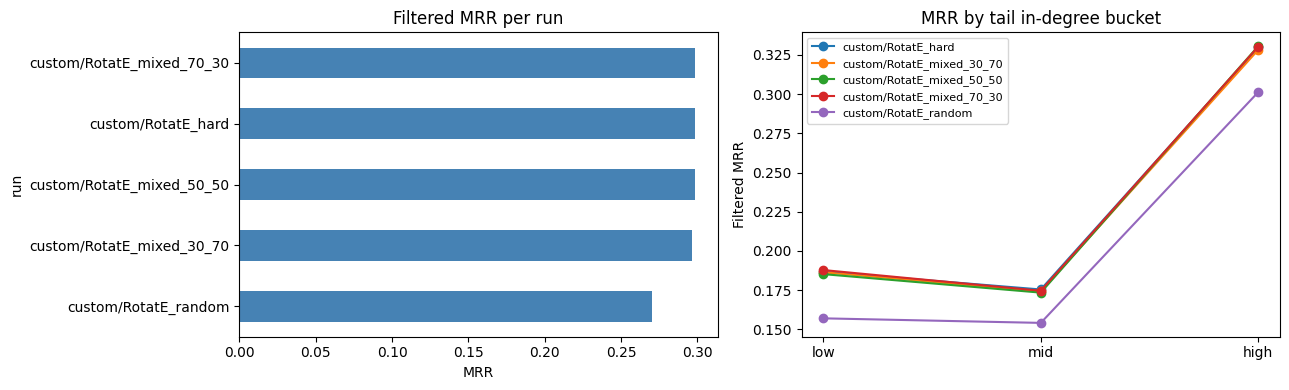

In [12]:
import matplotlib.pyplot as plt

if df.empty:
    print("No checkpoints found; run sections C–E first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    df["mrr"].sort_values().plot.barh(ax=axes[0], color="steelblue")
    axes[0].set_title("Filtered MRR per run")
    axes[0].set_xlabel("MRR")
    rotate_baseline = df.loc[df.index.str.contains("pykeen_RotatE"), "mrr"]
    if not rotate_baseline.empty:
        axes[0].axvline(rotate_baseline.mean(), color="red", linestyle="--",
                        linewidth=1, label="RotatE baseline")
        axes[0].legend()

    cols = ["tail_degree.low", "tail_degree.mid", "tail_degree.high"]
    df[cols].T.plot(ax=axes[1], marker="o")
    axes[1].set_title("MRR by tail in-degree bucket")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(["low", "mid", "high"])
    axes[1].set_ylabel("Filtered MRR")
    axes[1].legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig("artifacts/d3_headline_figures.png", dpi=150)
    plt.show()

## I. Notes for graders

* Two-stage negative sampling lives in three small modules:
  * `code/negative_sampling.py` — Bernoulli corruption + train-triple filter.
  * `code/score_candidates.py` — batched scoring of candidate triples.
  * `code/select_candidates.py` — `random` / `hard` / `mixed` selection from the scored pool.
* The two training drivers are `code/train_baseline_kge.py` (PyKEEN pipeline) and
  `code/train_rotate_custom.py` (custom loop). The latter calls
  `model.post_parameter_update()` after every optimiser step to keep RotatE's relation
  embeddings on the complex unit circle, mirroring what PyKEEN's pipeline does internally.
  This step was essential for the NSSALoss to converge under our custom loop.
* `code/evaluate_slices.py` and `code/qualitative_examples.py` are pure post-hoc tools that
  consume `trained_model.pkl` files and do not retrain anything.
* The full set of artefacts (summaries, learning-curve PNGs, `slices.json`, `qualitative.md`)
  is committed under `artifacts/` for reference.
